<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Inverse_Fourier_Transform_of_Pi_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# Inverse Fourier Transform of $\pi$: Exact Theory and Finite Computation

## Motivation

Recovering a time signal from a uniform spectrum exposes a practical gap between continuous Fourier analysis and computation on a finite array. Across an unlimited frequency axis, the inverse transform is a Dirac delta with a specified integral weight; within a sampled calculation, that weight must occupy a finite sample interval. Preserving this weight connects the analytical solution to a correctly scaled discrete transform and prevents the plotted peak height from being mistaken for a physical pulse amplitude.

## Symbols and Computational Terms

Moving between a continuous spectrum and a finite array changes the roles of time spacing and frequency spacing. Separate symbols for these quantities preserve the connection between the continuous integral and its discrete counterpart, including their units.

| Symbol or term | Definition and conditions |
| --- | --- |
| $\pi$ | Exact mathematical constant; the prescribed spectrum has dimensionless amplitude $\pi$ |
| $i$ | Imaginary unit, with $i^2=-1$ |
| $e$ | Base of the natural exponential |
| $t$ | Continuous time, measured in seconds if dimensional time is used |
| $\nu$ | Ordinary frequency in cycles per second |
| $\omega$ | Angular frequency in radians per second |
| $f(t)$ | Continuous time signal or distribution; inverse seconds for the dimensionless spectrum used here |
| $F(\omega)$ | Spectrum expressed in angular frequency |
| $G(\nu)$ | The same spectrum expressed in ordinary frequency |
| $\delta(t)$ | Dirac delta distribution, with units of inverse time |
| $\phi(t)$ | Smooth test function that decreases rapidly, together with all its derivatives |
| $\mathcal F$, $\mathcal F^{-1}$ | Continuous Fourier transform and inverse under the stated angular-frequency convention |
| $\longleftrightarrow$ | A transform pair under the convention accompanying the equation |
| $N$ | Positive integer number of samples and frequency bins |
| $n$, $k$ | Time-sample and frequency-bin indices, respectively, from $0$ to $N-1$ |
| $\delta[n]$ | Discrete unit impulse, equal to one at $n=0$ and zero at every other index in the array |
| $x[n]$ | Discrete time sequence, scaled to represent an impulse of area $\pi$ |
| $X[k]$ | Discrete spectrum including the continuous-transform sampling scale |
| $\Delta t$ | Positive sampling interval |
| $T$ | Duration of one DFT period, equal to $N\Delta t$ |
| $\Delta\nu$, $\Delta\omega$ | Spacing between ordinary-frequency and angular-frequency bins |
| $\Omega$ | Positive angular-frequency cutoff of a rectangular spectrum |
| $F_\Omega(\omega)$, $f_\Omega(t)$ | Spectrum with cutoff $\Omega$ and its continuous inverse |
| $w$ | Width between the first zeros surrounding the central peak of $f_\Omega(t)$ |
| $\pi_{\mathrm{fp}}$ | Stored floating point approximation to $\pi$ |
| $\widehat x[n]$, $\widehat X[k]$ | Computed time samples and reconstructed spectral bins |
| $E_A$ | Absolute error in the discrete impulse area relative to $\pi_{\mathrm{fp}}$ |
| $E_X$ | Maximum absolute spectral round-trip error relative to $\pi_{\mathrm{fp}}$ |
| $\varepsilon_{64}$ | Spacing between one and the next larger IEEE 754 binary64 value |
| $\lvert\cdot\rvert$, $\max$ | Complex magnitude or absolute value, and maximum over the indicated indices |
| $\propto$ | Proportional scaling under the stated conditions |
| FT, IFT | Continuous Fourier transform and inverse Fourier transform |
| DFT, IDFT | Discrete Fourier transform and inverse discrete Fourier transform |
| FFT, IFFT | Fast algorithms for evaluating the DFT and IDFT |
| `sp.pi`, `sp.Rational` | SymPy representations of exact $\pi$ and rational numbers |
| `mp.pi`, `mp.dps` | mpmath's numerical $\pi$ and working precision in decimal digits |
| `np.pi` | NumPy's floating point approximation to $\pi$ |
| `float64`, `complex128` | Binary64 real arithmetic and complex arithmetic with two binary64 components |
| `fftshift`, `ifftshift` | Array permutations between standard FFT order and centered display order |

## Fundamental Theory

A spectrum that stays constant across the entire frequency axis requires a generalized interpretation of the inverse integral. Within distribution theory, the Dirac delta describes a concentrated integral weight, permitting Fourier inversion beyond ordinary integrable functions. [1](https://dlmf.nist.gov/1.17)

For time $t$ and angular frequency $\omega$, choose the transform pair

$$
F(\omega)=\int_{-\infty}^{\infty}f(t)e^{-i\omega t}\,dt,
\qquad
f(t)=\frac{1}{2\pi}\int_{-\infty}^{\infty}F(\omega)e^{i\omega t}\,d\omega.
$$

The integrals apply in their ordinary sense for suitable functions and extend to tempered distributions by duality. For a smooth, rapidly decreasing test function $\phi(t)$, the defining action of the delta is

$$
\int_{-\infty}^{\infty}\delta(t)\phi(t)\,dt=\phi(0).
$$

Evaluating the forward transform of the proposed impulse fixes its coefficient without assigning a finite height to the distribution,

$$
\mathcal F\{\pi\delta(t)\}
=\pi e^{-i\omega\cdot0}
=\pi.
$$

Inverting this identity yields

$$
\boxed{\mathcal F^{-1}\{\pi\}=\pi\delta(t).}
$$

For ordinary frequency $\nu$, preserving the same physical spectrum requires a change of variable,

$$
\omega=2\pi\nu,
\qquad
G(\nu)=F(2\pi\nu).
$$

Substitution into the transform integrals gives

$$
G(\nu)=\int_{-\infty}^{\infty}f(t)e^{-2\pi i\nu t}\,dt,
\qquad
f(t)=\int_{-\infty}^{\infty}G(\nu)e^{2\pi i\nu t}\,d\nu.
$$

SymPy's `fourier_transform()` and `inverse_fourier_transform()` use this ordinary-frequency convention. Both conventions above assign the amplitude $\pi$ to the transform of $\pi\delta(t)$; other normalization choices require their own coefficient calculation. [2](https://docs.sympy.org/latest/modules/integrals/integrals.html#sympy.integrals.transforms.fourier_transform)

## Sampling Scale and Computational Implementation

A finite array carries the impulse weight in one sample whose contribution to a time integral includes the sampling interval. As that interval decreases, preservation of the area requires a corresponding increase in the sample amplitude.

For $N$ samples and a positive interval $\Delta t$, define the discrete impulse and its scaled sequence by

$$
\delta[n]=
\begin{cases}
1,&n=0,\\
0,&n\ne0,
\end{cases}
\qquad
x[n]=\frac{\pi}{\Delta t}\delta[n],
\qquad 0\le n<N.
$$

Multiplying the sample sum by $\Delta t$ recovers the prescribed area,

$$
\Delta t\sum_{n=0}^{N-1}x[n]=\pi.
$$

Incorporating the same scale into the DFT produces the mutually inverse definitions

$$
X[k]=\Delta t\sum_{n=0}^{N-1}x[n]e^{-2\pi i kn/N},
$$

$$
x[n]=\frac{1}{N\Delta t}\sum_{k=0}^{N-1}X[k]e^{2\pi i kn/N}.
$$

Only the sample at zero contributes to the forward sum. Substituting its amplitude gives the exact finite pair

$$
X[k]=\Delta t\frac{\pi}{\Delta t}=\pi,
\qquad
\boxed{\frac{\pi}{\Delta t}\delta[n]\longleftrightarrow X[k]=\pi.}
$$

With NumPy's default `norm="backward"`, the corresponding operations are `X = dt * np.fft.fft(x)` and `x = np.fft.ifft(X) / dt`. Standard array order places the impulse at index zero; `fftshift` moves it to the center for display, and `ifftshift` restores standard order for a subsequent transform. [3](https://numpy.org/doc/stable/reference/routines.fft.html)

The record duration fixes the spacing of the spectral samples,

$$
T=N\Delta t,
\qquad
\Delta\nu=\frac{1}{T},
\qquad
\Delta\omega=\frac{2\pi}{T}.
$$

At fixed $\Delta t$, increasing $N$ refines the frequency spacing and extends the record duration. Reducing $\Delta t$ raises the Nyquist angular frequency $\pi/\Delta t$, expanding the frequency interval represented by the sampled data.

For exact symbolic arithmetic, the rational interval $\Delta t=1/100$ gives the sample amplitude $100\pi$. Constructing this interval with `sp.Rational(1, 100)` preserves its exact value, and `sp.pi` retains the symbolic constant until a numerical evaluation is requested. [4](https://docs.sympy.org/latest/modules/evalf.html)

With mpmath, `mp.dps` selects the working decimal precision. Generating `mp.pi` within that precision context, together with extra guard digits for intermediate arithmetic, supports a direct DFT at a chosen numerical accuracy; increasing precision and checking agreement provides an empirical convergence check. [5](https://mpmath.readthedocs.io/en/latest/basics.html)

## Finite Bandwidth and Distributional Limits

Restricting a spectrum to a finite interval spreads its inverse across time. For an ideal rectangular cutoff, destructive interference produces oscillating side lobes around a central peak, connecting the concentrated impulse to a waveform with finite width.

To isolate the effect of bandwidth, retain amplitude $\pi$ within a positive angular-frequency cutoff $\Omega$,

$$
F_\Omega(\omega)=
\begin{cases}
\pi,&\lvert\omega\rvert\le\Omega,\\
0,&\lvert\omega\rvert>\Omega.
\end{cases}
$$

Applying the inverse integral over this interval gives

$$
f_\Omega(t)
=\frac{1}{2}\int_{-\Omega}^{\Omega}e^{i\omega t}\,d\omega
=\frac{\sin(\Omega t)}{t},
\qquad t\ne0.
$$

Continuity supplies the value at the origin,

$$
f_\Omega(0)=\lim_{t\to0}\frac{\sin(\Omega t)}{t}=\Omega.
$$

The first zeros lie at $t=\pm\pi/\Omega$, giving the width $w$ between them,

$$
w=\frac{2\pi}{\Omega},
\qquad
w\propto\Omega^{-1}.
$$

As $\Omega$ increases, convergence to the delta concerns integration against a test function. Its precise form is

$$
\lim_{\Omega\to\infty}
\int_{-\infty}^{\infty}f_\Omega(t)\phi(t)\,dt
=\pi\phi(0).
$$

At a fixed nonzero time, the numerator continues to oscillate as the cutoff grows, precluding ordinary pointwise convergence. The distributional interpretation preserves the limiting integral weight despite these oscillations. [1](https://dlmf.nist.gov/1.17)

At the Nyquist cutoff $\Omega=\pi/\Delta t$, sampling this continuous waveform at integer multiples of $\Delta t$ gives

$$
f_\Omega(n\Delta t)=
\begin{cases}
\pi/\Delta t,&n=0,\\
0,&n\ne0.
\end{cases}
$$

The single visible sample therefore coexists with a continuous waveform that has side lobes between sample locations. Under the DFT's periodic interpretation, a finite record repeats with period $T$, introducing a further difference from an isolated continuous impulse.

An ideal rectangular cutoff is itself an abstraction. Its inverse extends to negative times and has infinite temporal support, so a physical causal filter requires a realizable response with its associated phase and transition band.

## Practical Observation and Numerical Checks

A sampled impulse plot displays an amplitude whose value changes with the chosen time interval. Comparing its discrete area with the recovered spectrum separates the intended transform scaling from numerical rounding and display choices.

For computed samples $\widehat x[n]$ and reconstructed bins $\widehat X[k]$, define two checks against the stored input value $\pi_{\mathrm{fp}}$,

$$
E_A=
\left\lvert\Delta t\sum_{n=0}^{N-1}\widehat x[n]-\pi_{\mathrm{fp}}\right\rvert,
\qquad
E_X=\max_{0\le k<N}\left\lvert\widehat X[k]-\pi_{\mathrm{fp}}\right\rvert.
$$

These checks measure consistency with the numerical input. A zero reported error is possible for this structured calculation, including cases in which rounding reproduces the stored constant exactly; the gap between $\pi_{\mathrm{fp}}$ and mathematical $\pi$ requires a separate comparison against a reference computed at greater precision.

For binary64 arithmetic, the spacing above one is

$$
\varepsilon_{64}=2^{-52}\approx2.22\times10^{-16}.
$$

This scale corresponds to roughly 16 significant decimal digits, with the error of a specific calculation also influenced by its operations and input values. Converting an already rounded binary64 value to an arbitrary precision type preserves that rounded input; computing the constant directly at the requested precision avoids carrying the initial loss forward. [5](https://mpmath.readthedocs.io/en/latest/basics.html)

| Observation | Expected behavior | Interpretation |
| --- | --- | --- |
| Impulse sample | Amplitude $\pi/\Delta t$ at the origin | Peak height changes with the sampling interval |
| Discrete area | $\Delta t\sum_n x[n]=\pi$ in exact arithmetic | The sample carries the intended integral weight |
| Real spectrum | Constant value $\pi$ at every bin | The impulse occupies the chosen time origin |
| Imaginary spectrum | Zero in exact arithmetic | The centered physical impulse has zero spectral phase |
| Spectral error $E_X$ | Zero or a small rounding residual | Agreement with the stored numerical input |
| Finite-bandwidth waveform | Central peak with oscillating side lobes | Sharp spectral truncation spreads the response across time |
| Peak width $w$ | Inversely proportional to $\Omega$ | Greater bandwidth permits a narrower central response |

In measurements, this bandwidth dependence connects spectral coverage to temporal resolution. The same calculation also checks FFT scaling without requiring a complicated signal, although a single impulse provides limited coverage of errors involving general phase patterns or spectral structure.

## Comparison of Representations

The continuous impulse and the discrete impulse preserve the same spectral amplitude under their respective scaled transforms. Their interpretation diverges at the time axis, where a distribution acts on test functions and an array assigns finite numbers to indexed samples.

| Representation | Treatment of $\pi$ | Time-domain object | Mathematical or computational status | Principal limitation |
| --- | --- | --- | --- | --- |
| Continuous Fourier analysis | Exact constant | $\pi\delta(t)$ | Exact identity in tempered distributions | Requires an unlimited constant spectrum |
| Finite DFT in exact arithmetic | Exact constant | $(\pi/\Delta t)\delta[n]$ | Exact algebraic identity at every bin | Finite sampling and periodic interpretation |
| SymPy | Symbolic `sp.pi` | Symbolic distribution or finite symbolic sequence | Preserves exact expressions and rational input | Automated evaluation depends on supported expressions |
| mpmath | Numerical constant at selected precision | Finite numerical sequence | Precision is adjustable and convergence is testable | Rounding persists at finite precision |
| NumPy FFT | Binary64 approximation for the stated types | Finite numerical sequence | Efficient calculation with measurable numerical residuals | Precision is fixed by the arithmetic type |
| Continuous rectangular spectrum | Exact amplitude within finite bandwidth | $\sin(\Omega t)/t$, with value $\Omega$ at zero | Exact inverse of the specified spectral model | Side lobes, infinite temporal support, and a noncausal idealization |

Under the stated angular-frequency convention, the inverse transform of a spectrum equal to $\pi$ everywhere is exactly $\pi\delta(t)$. A scaled finite DFT reproduces the constant bins exactly in symbolic arithmetic, and numerical implementations approximate that same pair at their chosen precision.

## Bibliography

Distribution theory specifies the interpretation of an ideal impulse and its bandwidth limit. The software documentation records the transform conventions and precision behavior governing the corresponding computations.

1. National Institute of Standards and Technology. (n.d.; accessed September 16, 2026). “§1.17 Integral and Series Representations of the Dirac Delta.” *NIST Digital Library of Mathematical Functions*, Chapter 1, *Algebraic and Analytic Methods*. Living online reference; volume, page range, and section DOI are inapplicable. [https://dlmf.nist.gov/1.17](https://dlmf.nist.gov/1.17).

2. SymPy Development Team. (n.d.; accessed September 16, 2026). “Integral Transforms: Fourier Transform and Inverse Fourier Transform.” *SymPy 1.14.0 Documentation*, Integrals module. Online software documentation; volume, page range, and page DOI are inapplicable. [Fourier transform documentation](https://docs.sympy.org/latest/modules/integrals/integrals.html#sympy.integrals.transforms.fourier_transform).

3. NumPy Developers. (n.d.; accessed September 16, 2026). “Discrete Fourier Transform.” *NumPy Reference Manual*. Online software documentation, including implementation details and normalization; volume, page range, and page DOI are inapplicable. [https://numpy.org/doc/stable/reference/routines.fft.html](https://numpy.org/doc/stable/reference/routines.fft.html).

4. SymPy Development Team. (n.d.; accessed September 16, 2026). “Numerical Evaluation.” *SymPy 1.14.0 Documentation*. Online software documentation; volume, page range, and page DOI are inapplicable. [https://docs.sympy.org/latest/modules/evalf.html](https://docs.sympy.org/latest/modules/evalf.html).

5. Johansson, F., and mpmath contributors. (n.d.; accessed September 16, 2026). “Basic Usage.” *mpmath Documentation*, latest development documentation. Online software documentation; volume, page range, and page DOI are inapplicable. [https://mpmath.readthedocs.io/en/latest/basics.html](https://mpmath.readthedocs.io/en/latest/basics.html).

In [ ]:
!uv pip install numpy matplotlib scipy

Exact continuous Fourier pair
----------------------------------------
f(t) = pi*DiracDelta(t)
F(ν) = pi
F⁻¹{π} = pi*DiracDelta(t)

Exact symbolic certificate: True

Exact symbolic finite DFT
----------------------------------------
Input impulse:
[100*pi, 0, 0, 0, 0, 0, 0, 0]

DFT:
[pi, pi, pi, pi, pi, pi, pi, pi]

Inverse DFT:
[100*pi, 0, 0, 0, 0, 0, 0, 0]

Every frequency bin equals π exactly: True

π to 100 decimal places
----------------------------------------
3.141592653589793238462643383279502884197169399375105820974944592307816406286208998628034825342117068

Arbitrary-precision DFT
----------------------------------------
First frequency bin:
3.141592653589793238462643383279502884197169399375105820974944592307816406286208998628034825342117068

Maximum |F[k] - π|:
0.0

NumPy float64 FFT
----------------------------------------
Central impulse amplitude: 314.15926535897933
Expected π / Δt: 314.15926535897933
Maximum FFT round-trip error: 0.000000e+00
Stored float64 π: 3.14159265

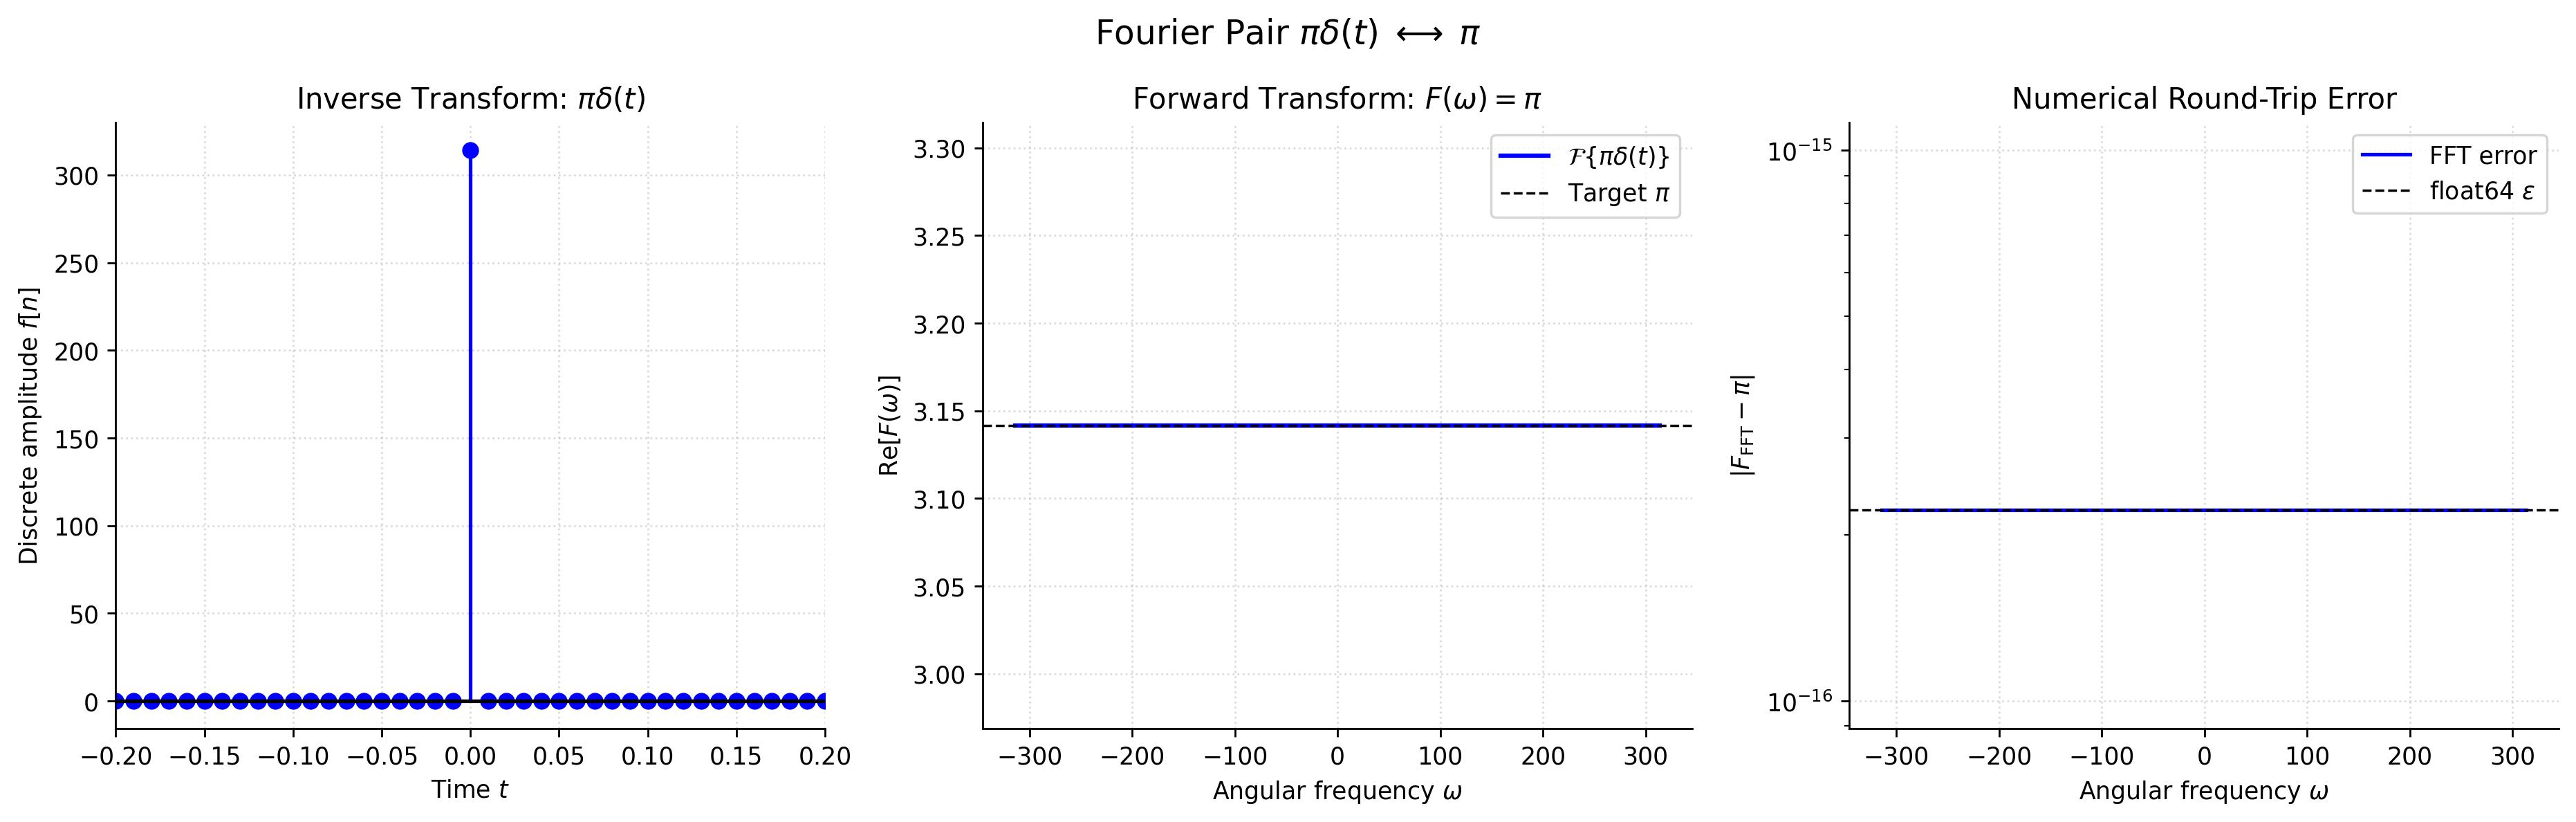

In [6]:
"""Verify the exact Fourier pair πδ(t) ↔ π symbolically and numerically.

Three numerical regimes are compared:

1. SymPy preserves π exactly and certifies πδ(t) ↔ π symbolically.
2. SymPy evaluates an exact finite DFT using rational arithmetic.
3. mpmath evaluates the corresponding DFT to arbitrary precision.
4. NumPy visualizes the finite float64 FFT representation.

SymPy uses ordinary frequency ν:

    F(ν) = ∫ f(t) exp(-2πiνt) dt,
    f(t) = ∫ F(ν) exp(2πiνt) dν.

The NumPy visualization also reports angular frequency ω = 2πν:

    F(ω) = ∫ f(t) exp(-iωt) dt,
    f(t) = (1 / 2π) ∫ F(ω) exp(iωt) dω.

Under either convention:

    πδ(t) ↔ π.
"""

import matplotlib.pyplot as plt
import mpmath as mp
import numpy as np
import sympy as sp


# --- Control Knobs ---

NUM_SAMPLES = 1024
EXACT_DFT_SAMPLES = 8
MP_DFT_SAMPLES = 32

TIME_STEP_EXACT = sp.Rational(1, 100)

PI_DECIMAL_PLACES = 100
GUARD_DIGITS = 20

FIGURE_DPI = 250
TIME_WINDOW = 0.20


# --- Derived Parameters ---

time_step = float(TIME_STEP_EXACT)

plt.rcParams["figure.dpi"] = FIGURE_DPI
plt.rcParams["savefig.dpi"] = FIGURE_DPI
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.linestyle"] = ":"
plt.rcParams["grid.alpha"] = 0.45


# --- Exact Continuous Fourier Pair ---

t, nu = sp.symbols("t nu", real=True)

exact_time_signal = sp.pi * sp.DiracDelta(t)

exact_spectrum = sp.fourier_transform(
    exact_time_signal,
    t,
    nu,
)

inverse_candidate = sp.pi * sp.DiracDelta(t)

inverse_certificate = sp.fourier_transform(
    inverse_candidate,
    t,
    nu,
)

assert exact_spectrum == sp.pi
assert inverse_certificate == sp.pi

print("Exact continuous Fourier pair")
print("----------------------------------------")
print("f(t) =", exact_time_signal)
print("F(ν) =", exact_spectrum)
print("F⁻¹{π} =", inverse_candidate)
print()
print(
    "Exact symbolic certificate:",
    inverse_certificate == sp.pi,
)
print()


# --- Exact Finite DFT ---

exact_impulse = [
    sp.pi / TIME_STEP_EXACT,
    *([sp.Integer(0)] * (EXACT_DFT_SAMPLES - 1)),
]

exact_dft = [
    sp.simplify(value * TIME_STEP_EXACT)
    for value in sp.fft(exact_impulse)
]

exact_inverse_dft = [
    sp.simplify(value / TIME_STEP_EXACT)
    for value in sp.ifft(
        [sp.pi] * EXACT_DFT_SAMPLES
    )
]

assert all(
    value == sp.pi
    for value in exact_dft
)

assert exact_inverse_dft == exact_impulse

print("Exact symbolic finite DFT")
print("----------------------------------------")
print("Input impulse:")
print(exact_impulse)
print()
print("DFT:")
print(exact_dft)
print()
print("Inverse DFT:")
print(exact_inverse_dft)
print()
print(
    "Every frequency bin equals π exactly:",
    all(value == sp.pi for value in exact_dft),
)
print()


# --- Arbitrary-Precision π ---

mp.mp.dps = PI_DECIMAL_PLACES + GUARD_DIGITS + 1

pi_mp = mp.pi

dt_mp = (
    mp.mpf(int(TIME_STEP_EXACT.p))
    / mp.mpf(int(TIME_STEP_EXACT.q))
)

print(
    f"π to {PI_DECIMAL_PLACES} decimal places"
)
print("----------------------------------------")
print(
    mp.nstr(
        pi_mp,
        PI_DECIMAL_PLACES + 1,
    )
)
print()


# --- Arbitrary-Precision DFT ---

mp_impulse = [
    mp.mpf("0")
    for _ in range(MP_DFT_SAMPLES)
]

mp_impulse[0] = pi_mp / dt_mp

mp_spectrum = []

for k_index in range(MP_DFT_SAMPLES):
    value = mp.fsum(
        mp_impulse[n_index]
        * mp.exp(
            -2
            * mp.pi
            * mp.j
            * k_index
            * n_index
            / MP_DFT_SAMPLES
        )
        for n_index in range(MP_DFT_SAMPLES)
    )

    mp_spectrum.append(
        value * dt_mp
    )

mp_error = max(
    abs(value - pi_mp)
    for value in mp_spectrum
)

print("Arbitrary-precision DFT")
print("----------------------------------------")
print("First frequency bin:")
print(
    mp.nstr(
        mp_spectrum[0].real,
        PI_DECIMAL_PLACES + 1,
    )
)
print()
print("Maximum |F[k] - π|:")
print(
    mp.nstr(
        mp_error,
        20,
    )
)
print()


# --- NumPy Inverse FFT ---

frequency_spectrum = np.full(
    NUM_SAMPLES,
    np.pi,
    dtype=np.complex128,
)

time_signal = (
    np.fft.fftshift(
        np.fft.ifft(
            np.fft.ifftshift(
                frequency_spectrum
            )
        )
    )
    / time_step
)

sample_index = np.arange(
    -NUM_SAMPLES // 2,
    NUM_SAMPLES // 2,
)

time_array = sample_index * time_step

frequency_hz = np.fft.fftshift(
    np.fft.fftfreq(
        NUM_SAMPLES,
        d=time_step,
    )
)

angular_frequency = (
    2.0
    * np.pi
    * frequency_hz
)


# --- NumPy Forward FFT ---

reconstructed_spectrum = (
    np.fft.fftshift(
        np.fft.fft(
            np.fft.ifftshift(
                time_signal
            )
        )
    )
    * time_step
)

absolute_error = np.abs(
    reconstructed_spectrum - np.pi
)

center_index = NUM_SAMPLES // 2
max_fft_error = np.max(absolute_error)

print("NumPy float64 FFT")
print("----------------------------------------")

print(
    "Central impulse amplitude:",
    f"{time_signal[center_index].real:.17g}",
)

print(
    "Expected π / Δt:",
    f"{np.pi / time_step:.17g}",
)

print(
    "Maximum FFT round-trip error:",
    f"{max_fft_error:.6e}",
)

print(
    "Stored float64 π:",
    f"{np.pi:.17g}",
)

print()


# --- Visualization ---

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.8),
)

axes[0].stem(
    time_array,
    time_signal.real,
    linefmt="blue",
    markerfmt="bo",
    basefmt="k-",
)

axes[0].set_xlim(
    -TIME_WINDOW,
    TIME_WINDOW,
)

axes[0].set_title(
    r"Inverse Transform: $\pi\delta(t)$"
)

axes[0].set_xlabel(
    r"Time $t$"
)

axes[0].set_ylabel(
    r"Discrete amplitude $f[n]$"
)


axes[1].plot(
    angular_frequency,
    reconstructed_spectrum.real,
    color="blue",
    linewidth=1.8,
    label=r"$\mathcal{F}\{\pi\delta(t)\}$",
)

axes[1].axhline(
    np.pi,
    color="black",
    linestyle="--",
    linewidth=1.0,
    label=r"Target $\pi$",
)

axes[1].set_title(
    r"Forward Transform: $F(\omega)=\pi$"
)

axes[1].set_xlabel(
    r"Angular frequency $\omega$"
)

axes[1].set_ylabel(
    r"$\operatorname{Re}[F(\omega)]$"
)

axes[1].legend()


machine_epsilon = np.finfo(
    np.float64
).eps

display_error = np.maximum(
    absolute_error,
    machine_epsilon,
)

axes[2].semilogy(
    angular_frequency,
    display_error,
    color="blue",
    linewidth=1.5,
    label="FFT error",
)

axes[2].axhline(
    machine_epsilon,
    color="black",
    linestyle="--",
    linewidth=1.0,
    label=r"float64 $\epsilon$",
)

axes[2].set_title(
    "Numerical Round-Trip Error"
)

axes[2].set_xlabel(
    r"Angular frequency $\omega$"
)

axes[2].set_ylabel(
    r"$|F_{\mathrm{FFT}}-\pi|$"
)

axes[2].legend()


fig.suptitle(
    r"Fourier Pair "
    r"$\pi\delta(t)"
    r"\;\longleftrightarrow\;"
    r"\pi$",
    fontsize=14,
)

fig.tight_layout()
plt.show()